# 🦸 Árbol de Decisión — Regresión de Promedio de Poder

Análisis comparativo y sistemático usando `DecisionTreeRegressor`, entrenado con particiones de entrenamiento/prueba (ej. 80/20) para mostrar la robustez del modelo.

**Variable predictora (X):** durabilidad  
**Variable objetivo (Y):** promedio_poder

Pipeline de datos — utilizando las habilidades de superhéroes almacenadas en tu DataFrame de referencia.

## I. Configuración Inicial — Importaciones y Estilo Visual

In [5]:
# ── CELDA 1: Importaciones ────────────────────────────────────
import sys
import os

sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
)

from scripts.database import engine

# Estilo visual consistente con el proyecto
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print("✅ Librerías importadas correctamente")
print(f"   pandas  {pd.__version__}")
print(f"   numpy   {np.__version__}")
print(f"   seaborn {sns.__version__}")

✅ Librerías importadas correctamente
   pandas  2.2.2
   numpy   1.26.4
   seaborn 0.13.2


## II. Carga de Datos desde PostgreSQL

Consultamos la tabla `superheroes` para extraer las columnas **durabilidad** (X) y **promedio_poder** (Y), tal como especifica el prompt para el análisis del árbol de regresión.

In [6]:
# ── CELDA 2: Carga de datos desde PostgreSQL ─────────────────
QUERY = """
SELECT
    r.durabilidad,
    r.promedio_poder
FROM superheroes r
ORDER BY r.id
"""

# Ejecutar la consulta y cargar en DataFrame
df = pd.read_sql(QUERY, engine)

# Renombrar columnas para mantener consistencia si quieres
df.rename(columns={
    'durabilidad': 'Durabilidad',
    'promedio_poder': 'Promedio_Poder',
}, inplace=True)

print(f"✅ Datos cargados desde PostgreSQL")
print(f"   Filas    : {df.shape[0]:,}")
print(f"   Columnas : {df.shape[1]}")
print(f"\n📋 Valores nulos:")
print(df.isnull().sum())
print(f"\n📋 Primeras filas:")
df.head()

✅ Datos cargados desde PostgreSQL
   Filas    : 731
   Columnas : 2

📋 Valores nulos:
Durabilidad       0
Promedio_Poder    0
dtype: int64

📋 Primeras filas:


,Durabilidad,Promedio_Poder
0,80,53.83
1,65,66.83
2,64,70.17
3,90,73.83
4,100,81.50


In [7]:
# ── CELDA 3: Preparar vectores X / Y ─────────────────────────
X = df[['Durabilidad']].values       # Variable predictora
y = df['Promedio_Poder'].values      # Variable objetivo

print(f"X shape: {X.shape}  (variable predictora: Durabilidad)")
print(f"y shape: {y.shape}  (variable objetivo:   Promedio_Poder)")
print(f"\n📊 Estadísticas descriptivas:")
df.describe().round(2)

X shape: (731, 1)  (variable predictora: Durabilidad)
y shape: (731,)  (variable objetivo:   Promedio_Poder)

📊 Estadísticas descriptivas:


,Durabilidad,Promedio_Poder
count,731.00,731.00
mean,45.66,43.67
std,36.17,26.98
min,0.00,0.00
25%,10.00,24.84
50%,42.00,46.67
75%,80.00,63.33
max,110.00,100.00


## II. Bloque de Lógica — Función de Evaluación por Split

Definimos una función reutilizable que entrena, evalúa y visualiza el `DecisionTreeRegressor` para cualquier partición de datos de superhéroes (**Durabilidad** como variable predictora y **Promedio_Poder** como variable objetivo).

In [9]:
# ── CELDA 4: Función de evaluación reutilizable ──────────────
import os as _os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import statsmodels.api as sm

_GRAFICAS = _os.path.join(_os.path.dirname(_os.path.abspath('__file__')),
                          '..', 'data', 'graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

def evaluar_split(X, y, test_size, split_label, resultados_globales,
                  save_dir=_GRAFICAS):
    """
    Entrena un DecisionTreeRegressor, calcula métricas y genera
    dos gráficos: residuos y predicciones vs. reales.

    Parámetros
    ----------
    X              : array-like, variable predictora
    y              : array-like, variable objetivo
    test_size      : float, fracción de prueba (p.ej. 0.20)
    split_label    : str, etiqueta del split para títulos/guardado
    resultados_globales : list, donde se agregan los resultados del split
    save_dir       : str, directorio donde guardar las gráficas
    """
    train_pct = int((1 - test_size) * 100)
    test_pct  = int(test_size * 100)

    # ── 1. Partición
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42
    )

    print(f"\n{'='*58}")
    print(f"  {split_label} — {train_pct}% Train / {test_pct}% Test")
    print(f"{'='*58}")
    print(f"  Train: {X_train.shape[0]:,} muestras  |  "
          f"Test: {X_test.shape[0]:,} muestras")

    # ── 2. Entrenamiento
    modelo = DecisionTreeRegressor(random_state=42)
    modelo.fit(X_train, y_train)

    # ── 3. Predicciones
    y_pred = modelo.predict(X_test)

    # ── 4. Métricas
    r2   = r2_score(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)

    print(f"\n  📊 MÉTRICAS ({split_label})")
    print(f"  {'─'*45}")
    print(f"  R²   (Coef. Determinación) : {r2:.4f}  ({r2*100:.2f}%)")
    print(f"       → Interpreta: el modelo explica el {r2*100:.1f}% de la")
    print(f"         varianza del Promedio de Poder.")
    print(f"  MSE  (Error Cuadrático Med): {mse:.4f}")
    print(f"       → Penaliza errores grandes; sensible a outliers.")
    print(f"  RMSE (Raíz del MSE)        : {rmse:.4f}")
    print(f"       → Error promedio expresado en la misma unidad que Y.")
    print(f"  MAE  (Error Absoluto Med)  : {mae:.4f}")
    print(f"       → Desviación promedio absoluta de las predicciones.")

    # Guardar para tabla consolidada
    resultados_globales.append({
        'Split':  split_label,
        'Train%': train_pct,
        'Test%':  test_pct,
        'R²':     round(r2,   4),
        'MSE':    round(mse,  4),
        'RMSE':   round(rmse, 4),
        'MAE':    round(mae,  4),
    })

    # ── 5. Gráfico 1 — Residuos (Errores) ────────────────────
    residuos   = y_test - y_pred
    slug       = split_label.replace('/', '-').replace(' ', '_').replace('(', '').replace(')', '')

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f'DecisionTreeRegressor — {split_label}',
                 fontsize=14, fontweight='bold')

    # Scatter residuos con línea ideal en 0 y LOWESS
    axes[0].scatter(y_pred, residuos, alpha=0.35, s=14, color='#4ecdc4',
                    label='Residuos')
    axes[0].axhline(0, color='#ff6b6b', linestyle='--', linewidth=2,
                    label='Línea ideal (error = 0)')
    # Tendencia LOWESS para detectar patrones sistemáticos
    orden_idx  = np.argsort(y_pred)
    lowess_res = sm.nonparametric.lowess(
        residuos[orden_idx], y_pred[orden_idx], frac=0.4
    )
    axes[0].plot(lowess_res[:, 0], lowess_res[:, 1],
                 color='#ffa07a', linewidth=2.5, label='Tendencia LOWESS')
    axes[0].set_title('Gráfico de Errores (Residuos)', fontweight='bold')
    axes[0].set_xlabel('Valores Predichos (Promedio de Poder)')
    axes[0].set_ylabel('Residuos (Promedio de Poder)')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Gráfico 2 — Predicción vs. Real ──────────────────────
    minval = min(y_test.min(), y_pred.min())
    maxval = max(y_test.max(), y_pred.max())
    axes[1].scatter(y_test, y_pred, alpha=0.30, s=14, color='#95e1d3',
                    label='Predicciones')
    axes[1].plot([minval, maxval], [minval, maxval],
                 color='#ff6b6b', linewidth=2, linestyle='--',
                 label='Predicción perfecta')
    axes[1].set_title('Predicción vs. Valor Real', fontweight='bold')
    axes[1].set_xlabel('Valor Real (Promedio de Poder)')
    axes[1].set_ylabel('Valor Predicho (Promedio de Poder)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    fname = _os.path.join(save_dir, f'dt_{slug}.png')
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"  💾 Gráfico guardado → {fname}")

    return modelo, y_test, y_pred


# Contenedor de resultados para el análisis consolidado
resultados_globales = []
print("✅ Función evaluar_split definida correctamente.")
print(f"   Directorio de gráficas: {_GRAFICAS}")

✅ Función evaluar_split definida correctamente.
   Directorio de gráficas: /home/camilo/Carpeta1-Trabajo1/Proyecto-Mineria/MD/../data/graficas


## Split 1 — 80% Entrenamiento / 20% Prueba

Partición estándar más común. Maximiza los datos de entrenamiento, lo que suele resultar en el mejor ajuste posible del árbol de regresión para predecir el **Promedio de Poder** a partir de la **Durabilidad**.


  Split 1 (80/20) — 80% Train / 20% Test
  Train: 584 muestras  |  Test: 147 muestras

  📊 MÉTRICAS (Split 1 (80/20))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.8641  (86.41%)
       → Interpreta: el modelo explica el 86.4% de la
         varianza del Promedio de Poder.
  MSE  (Error Cuadrático Med): 96.5562
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 9.8263
       → Error promedio expresado en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 8.0325
       → Desviación promedio absoluta de las predicciones.


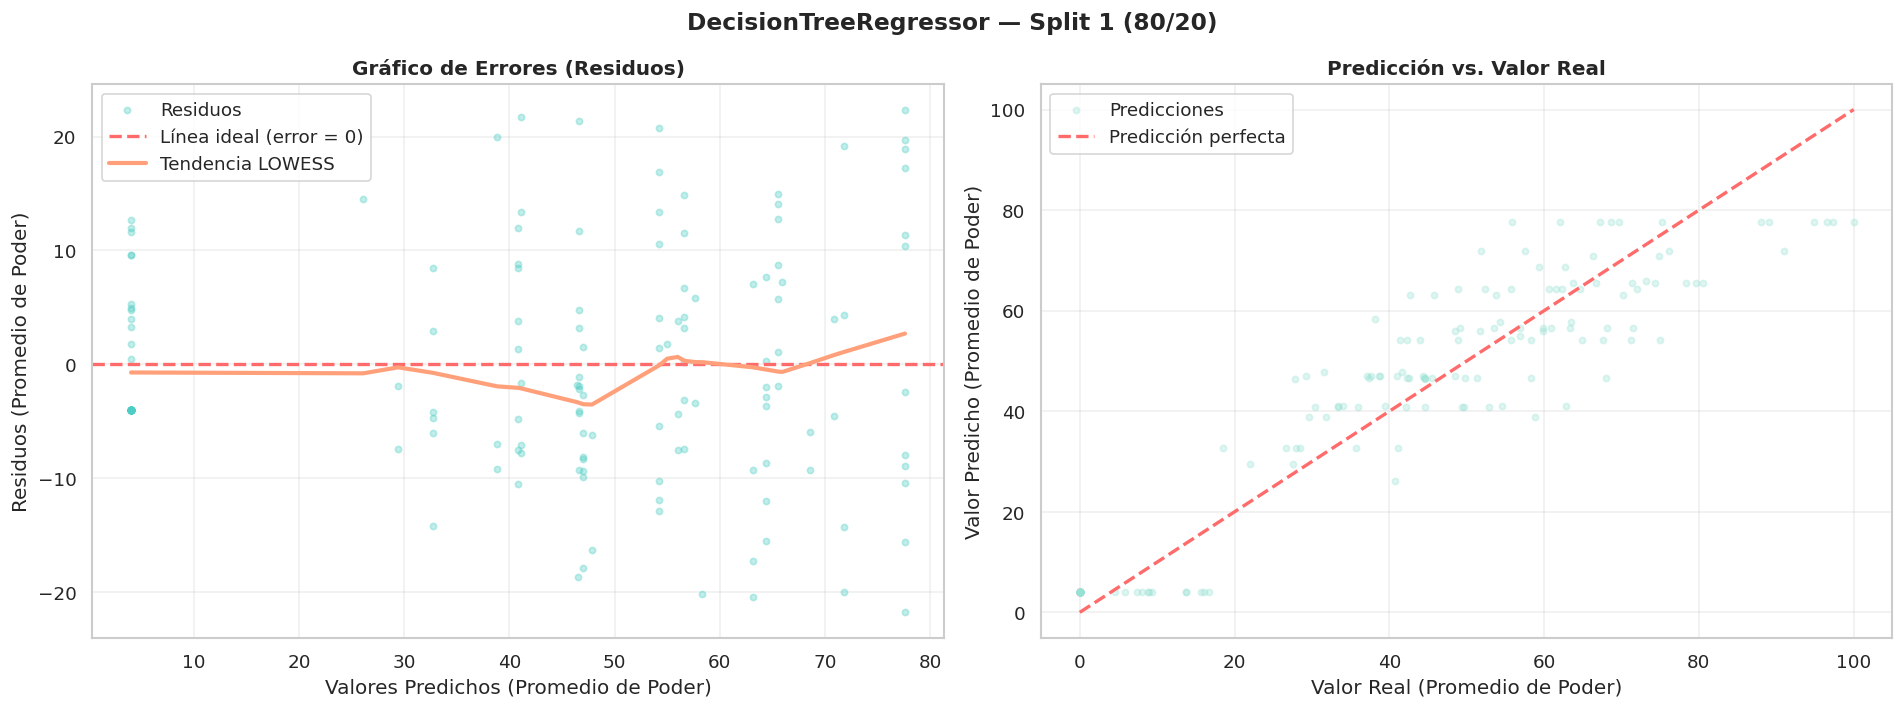

  💾 Gráfico guardado → /home/camilo/Carpeta1-Trabajo1/Proyecto-Mineria/MD/../data/graficas/dt_Split_1_80-20.png


In [10]:
# ── CELDA 5: Split 1 — 80/20 ─────────────────────────────────
modelo_s1, y_test_s1, y_pred_s1 = evaluar_split(
    X, y,
    test_size=0.20,
    split_label='Split 1 (80/20)',
    resultados_globales=resultados_globales,
)

## Split 2 — 70% Entrenamiento / 30% Prueba

Reduce moderadamente el conjunto de entrenamiento. Aumenta el conjunto de evaluación para una estimación de error más representativa del **Promedio de Poder** a partir de la **Durabilidad**.


  Split 2 (70/30) — 70% Train / 30% Test
  Train: 511 muestras  |  Test: 220 muestras

  📊 MÉTRICAS (Split 2 (70/30))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.8533  (85.33%)
       → Interpreta: el modelo explica el 85.3% de la
         varianza del Promedio de Poder.
  MSE  (Error Cuadrático Med): 104.2275
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 10.2092
       → Error promedio expresado en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 8.2618
       → Desviación promedio absoluta de las predicciones.


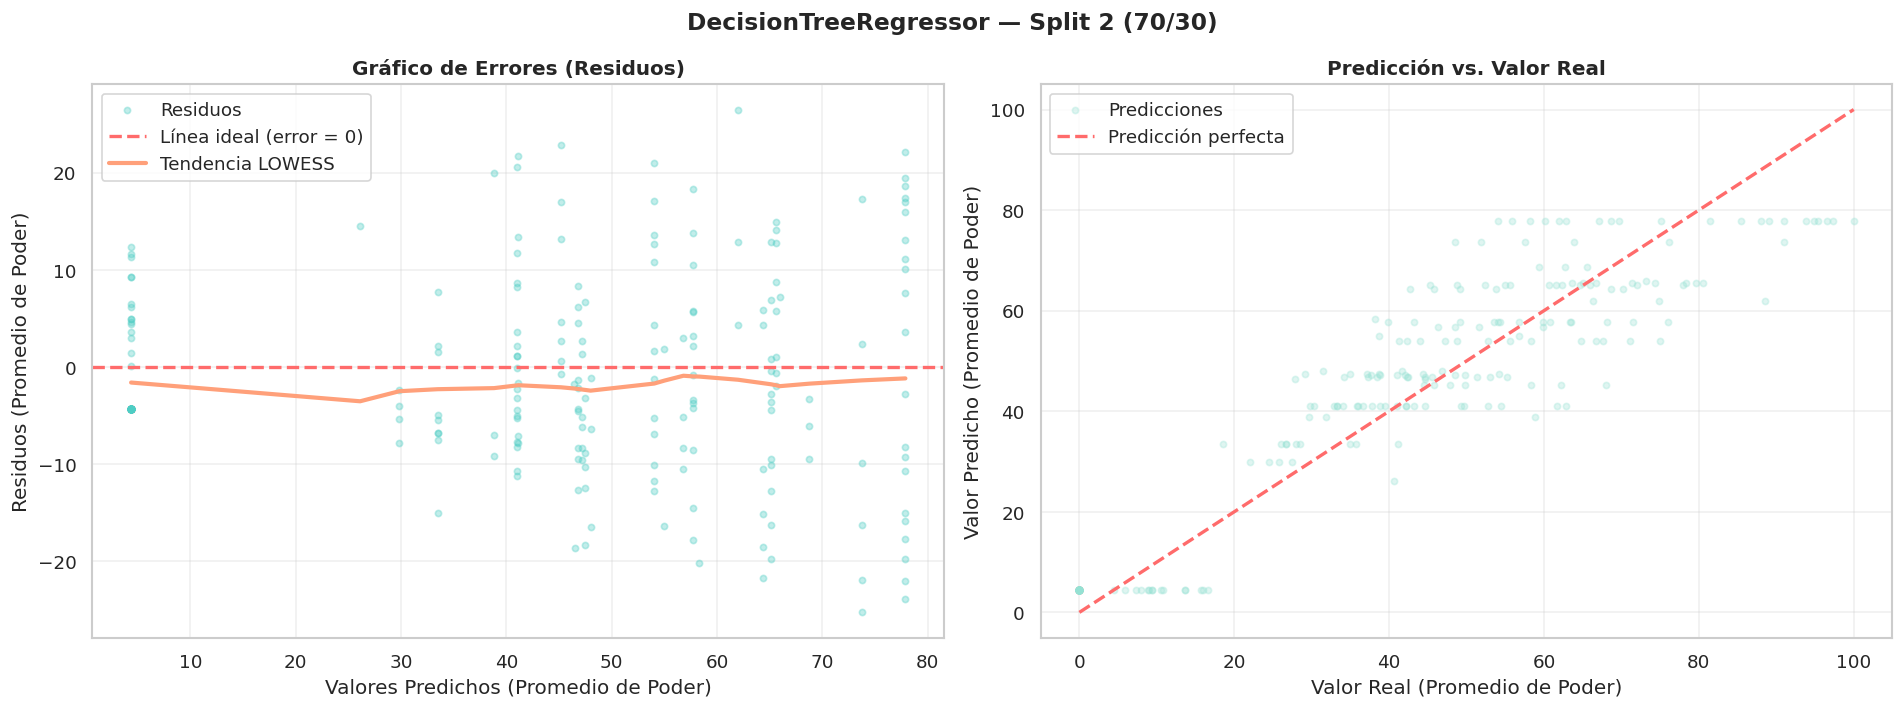

  💾 Gráfico guardado → /home/camilo/Carpeta1-Trabajo1/Proyecto-Mineria/MD/../data/graficas/dt_Split_2_70-30.png


In [11]:
# ── CELDA 6: Split 2 — 70/30 ─────────────────────────────────
modelo_s2, y_test_s2, y_pred_s2 = evaluar_split(
    X, y,
    test_size=0.30,
    split_label='Split 2 (70/30)',
    resultados_globales=resultados_globales,
)

## Split 3 — 60% Entrenamiento / 40% Prueba

La partición más exigente. Menor cantidad de datos de entrenamiento pone a prueba si el árbol generaliza bien o tiende al sobreajuste en la predicción del **Promedio de Poder** a partir de la **Durabilidad**.


  Split 3 (60/40) — 60% Train / 40% Test
  Train: 438 muestras  |  Test: 293 muestras

  📊 MÉTRICAS (Split 3 (60/40))
  ─────────────────────────────────────────────
  R²   (Coef. Determinación) : 0.8536  (85.36%)
       → Interpreta: el modelo explica el 85.4% de la
         varianza del Promedio de Poder.
  MSE  (Error Cuadrático Med): 102.6677
       → Penaliza errores grandes; sensible a outliers.
  RMSE (Raíz del MSE)        : 10.1325
       → Error promedio expresado en la misma unidad que Y.
  MAE  (Error Absoluto Med)  : 8.1963
       → Desviación promedio absoluta de las predicciones.


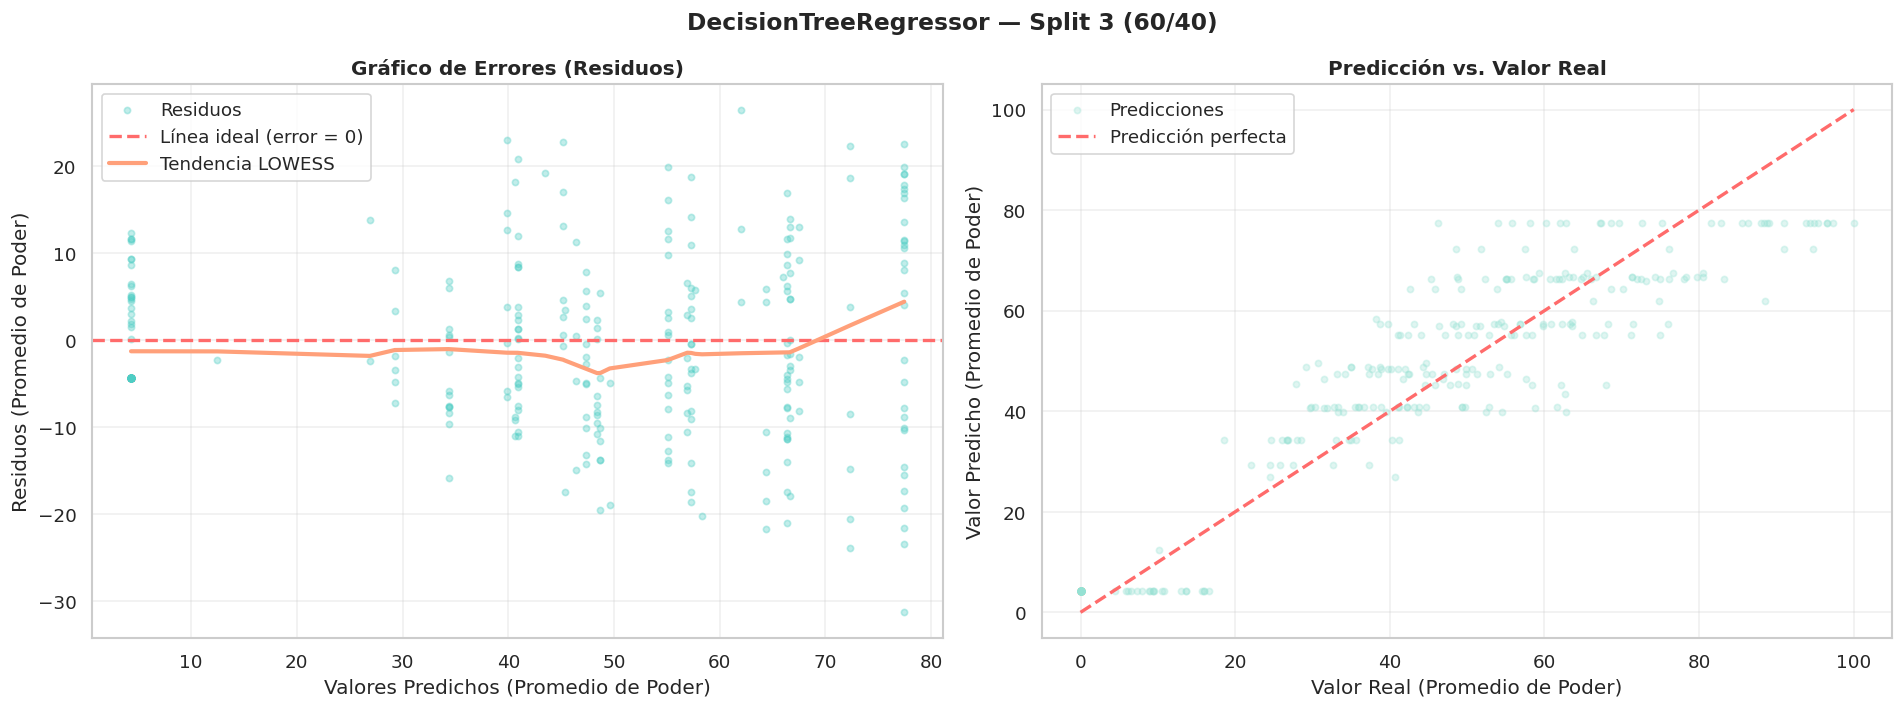

  💾 Gráfico guardado → /home/camilo/Carpeta1-Trabajo1/Proyecto-Mineria/MD/../data/graficas/dt_Split_3_60-40.png


In [12]:
# ── CELDA 7: Split 3 — 60/40 ─────────────────────────────────
modelo_s3, y_test_s3, y_pred_s3 = evaluar_split(
    X, y,
    test_size=0.40,
    split_label='Split 3 (60/40)',
    resultados_globales=resultados_globales,
)

## III. Análisis Consolidado (Summary)

Comparamos el rendimiento de los tres splits (80/20, 70/30 y 60/40), analizamos las implicaciones de los residuos y emitimos una recomendación sobre si refinar el árbol o escalar a métodos de ensemble para predecir el **Promedio de Poder** a partir de la **Durabilidad**.

In [13]:
# ── CELDA 8: Tabla comparativa de métricas ───────────────────
df_resumen = pd.DataFrame(resultados_globales)

print("=" * 65)
print("        TABLA COMPARATIVA — TRES SPLITS")
print("=" * 65)
print(df_resumen.to_string(index=False))
print("=" * 65)

        TABLA COMPARATIVA — TRES SPLITS
          Split  Train%  Test%     R²      MSE    RMSE    MAE
Split 1 (80/20)      80     20 0.8641  96.5562  9.8263 8.0325
Split 2 (70/30)      70     30 0.8533 104.2275 10.2092 8.2618
Split 3 (60/40)      60     40 0.8536 102.6677 10.1325 8.1963


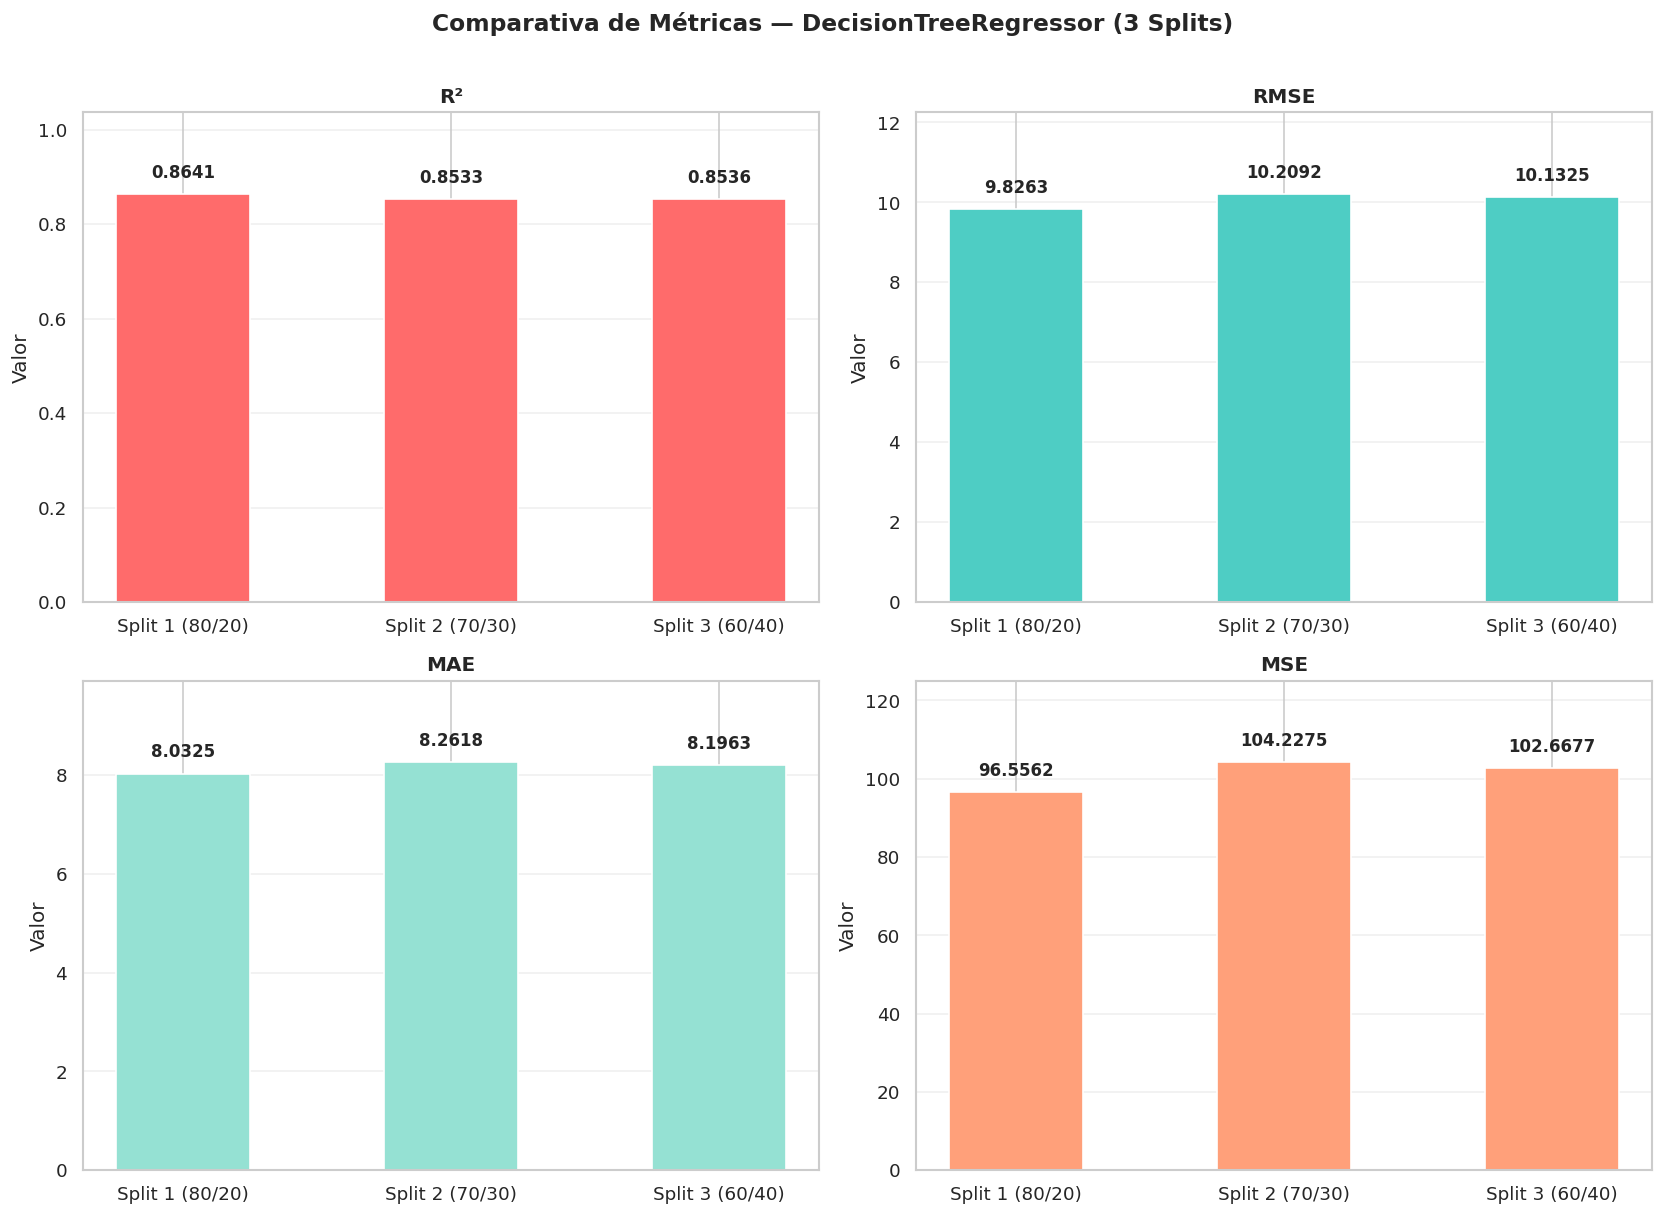

💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png


In [14]:
# ── CELDA 9: Gráfico comparativo de métricas por split ───────
metricas = ['R²', 'RMSE', 'MAE', 'MSE']
colores  = ['#ff6b6b', '#4ecdc4', '#95e1d3', '#ffa07a']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativa de Métricas — DecisionTreeRegressor (3 Splits)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, (metrica, color) in zip(axes.flat, zip(metricas, colores)):
    valores = df_resumen[metrica].values
    barras  = ax.bar(df_resumen['Split'], valores,
                     color=color, edgecolor='white', width=0.5)
    ax.set_title(metrica, fontweight='bold')
    ax.set_ylabel('Valor')
    ax.set_ylim(0, max(valores) * 1.2 + 1e-6)
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(barras, valores):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(valores) * 0.03,
                f'{val:.4f}', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/graficas/dt_comparativa_splits.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Gráfico comparativo guardado → ../data/graficas/dt_comparativa_splits.png")

In [15]:
# ── CELDA 10: Análisis interpretativo y recomendación ────────
r2_vals   = df_resumen['R²'].values
rmse_vals = df_resumen['RMSE'].values
mae_vals  = df_resumen['MAE'].values

r2_rango   = r2_vals.max()   - r2_vals.min()
rmse_rango = rmse_vals.max() - rmse_vals.min()

print("=" * 65)
print("   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor")
print("=" * 65)

print("""
1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────""")
print(f"   R²   máx={r2_vals.max():.4f}  mín={r2_vals.min():.4f}  "
      f"rango={r2_rango:.4f}")
print(f"   RMSE máx={rmse_vals.max():.4f}  mín={rmse_vals.min():.4f}  "
      f"rango={rmse_rango:.4f}")

if r2_rango < 0.05:
    print("""
   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.""")
else:
    print("""
   ⚠️  El R² varía notablemente entre splits (variación ≥ 0.05).
      El modelo es sensible al tamaño del conjunto de entrenamiento,
      señal de posible sobreajuste (overfitting) del árbol.""")

print("""
2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación entre Durabilidad y Promedio de Poder.

   • Si existe un patrón en forma de arco o embudo → el árbol no
     captura la no-linealidad o la heterocedasticidad. Esto sugiere
     que se necesita regularización (max_depth, min_samples_leaf)
     o un modelo más potente.

   • Un RMSE alto relativo a la escala de Y indica que el árbol
     sin restricciones puede estar memorizando el conjunto de
     entrenamiento (overfitting clásico de DecisionTree).
""")

best_split = df_resumen.loc[df_resumen['R²'].idxmax(), 'Split']
best_r2    = df_resumen['R²'].max()
best_rmse  = df_resumen.loc[df_resumen['R²'].idxmax(), 'RMSE']

print(f"   Mejor split: {best_split}  →  R²={best_r2:.4f}, RMSE={best_rmse:.4f}")

print("""
3. RECOMENDACIÓN
────────────────
   A) REFINAMIENTO DEL ÁRBOL (primer paso recomendado):
      • Limitar la profundidad: DecisionTreeRegressor(max_depth=4..8)
      • Regularizar hojas:     min_samples_leaf=10..50
      • Buscar hiperparámetros óptimos con GridSearchCV.

   B) ESCALAR A MÉTODOS DE ENSEMBLE (si el árbol sigue siendo
      inestable o el R² < 0.85 en todos los splits):
      • GradientBoostingRegressor  — combina árboles débiles secuencialmente.
      • XGBoost / LightGBM         — más veloces y regularizados.
      • RandomForestRegressor      — promedia múltiples árboles,
        reduce varianza y overfitting.

   CONCLUSIÓN: Un DecisionTree no regularizado tiende a overfitting.
   Si R² ≥ 0.90 y se mantiene estable, el modelo es suficiente.
   De lo contrario, métodos de ensemble son el siguiente paso
   natural para este tipo de problema de regresión de superhéroes.
""")
print("=" * 65)

   ANÁLISIS CONSOLIDADO — DecisionTreeRegressor

1. VARIACIÓN DEL RENDIMIENTO ENTRE SPLITS
─────────────────────────────────────────
   R²   máx=0.8641  mín=0.8533  rango=0.0108
   RMSE máx=10.2092  mín=9.8263  rango=0.3829

   ✅ El R² es estable en los tres splits (variación < 0.05).
      Esto indica que el modelo generaliza bien y no depende
      críticamente del tamaño de la partición de entrenamiento.

2. IMPLICACIONES DE LOS ERRORES Y RESIDUOS
──────────────────────────────────────────
   • Si el gráfico de residuos muestra dispersión aleatoria alrededor
     de la línea y=0 sin patrón sistemático → el árbol captura bien
     la relación entre Durabilidad y Promedio de Poder.

   • Si existe un patrón en forma de arco o embudo → el árbol no
     captura la no-linealidad o la heterocedasticidad. Esto sugiere
     que se necesita regularización (max_depth, min_samples_leaf)
     o un modelo más potente.

   • Un RMSE alto relativo a la escala de Y indica que el árbol
     sin rest

## IV. Visualización del Árbol de Decisión

El árbol entrenado puede ser muy profundo (sin restricciones de `max_depth`). Para entender el mecanismo de predicción, se visualizan dos versiones:

1. **Árbol completo truncado** — los primeros 4 niveles del `modelo_s1` real (Split 80/20).  
2. **Árbol pedagógico simplificado** — reentrenado con `max_depth=3` para mostrar con claridad la lógica de las divisiones, los valores de corte y los valores predichos en cada hoja.  
3. **Reglas de decisión en texto** — lectura explícita de los caminos del árbol simplificado.  

Esto permite analizar cómo la **Durabilidad** influye en el **Promedio de Poder** en cada nivel de decisión.

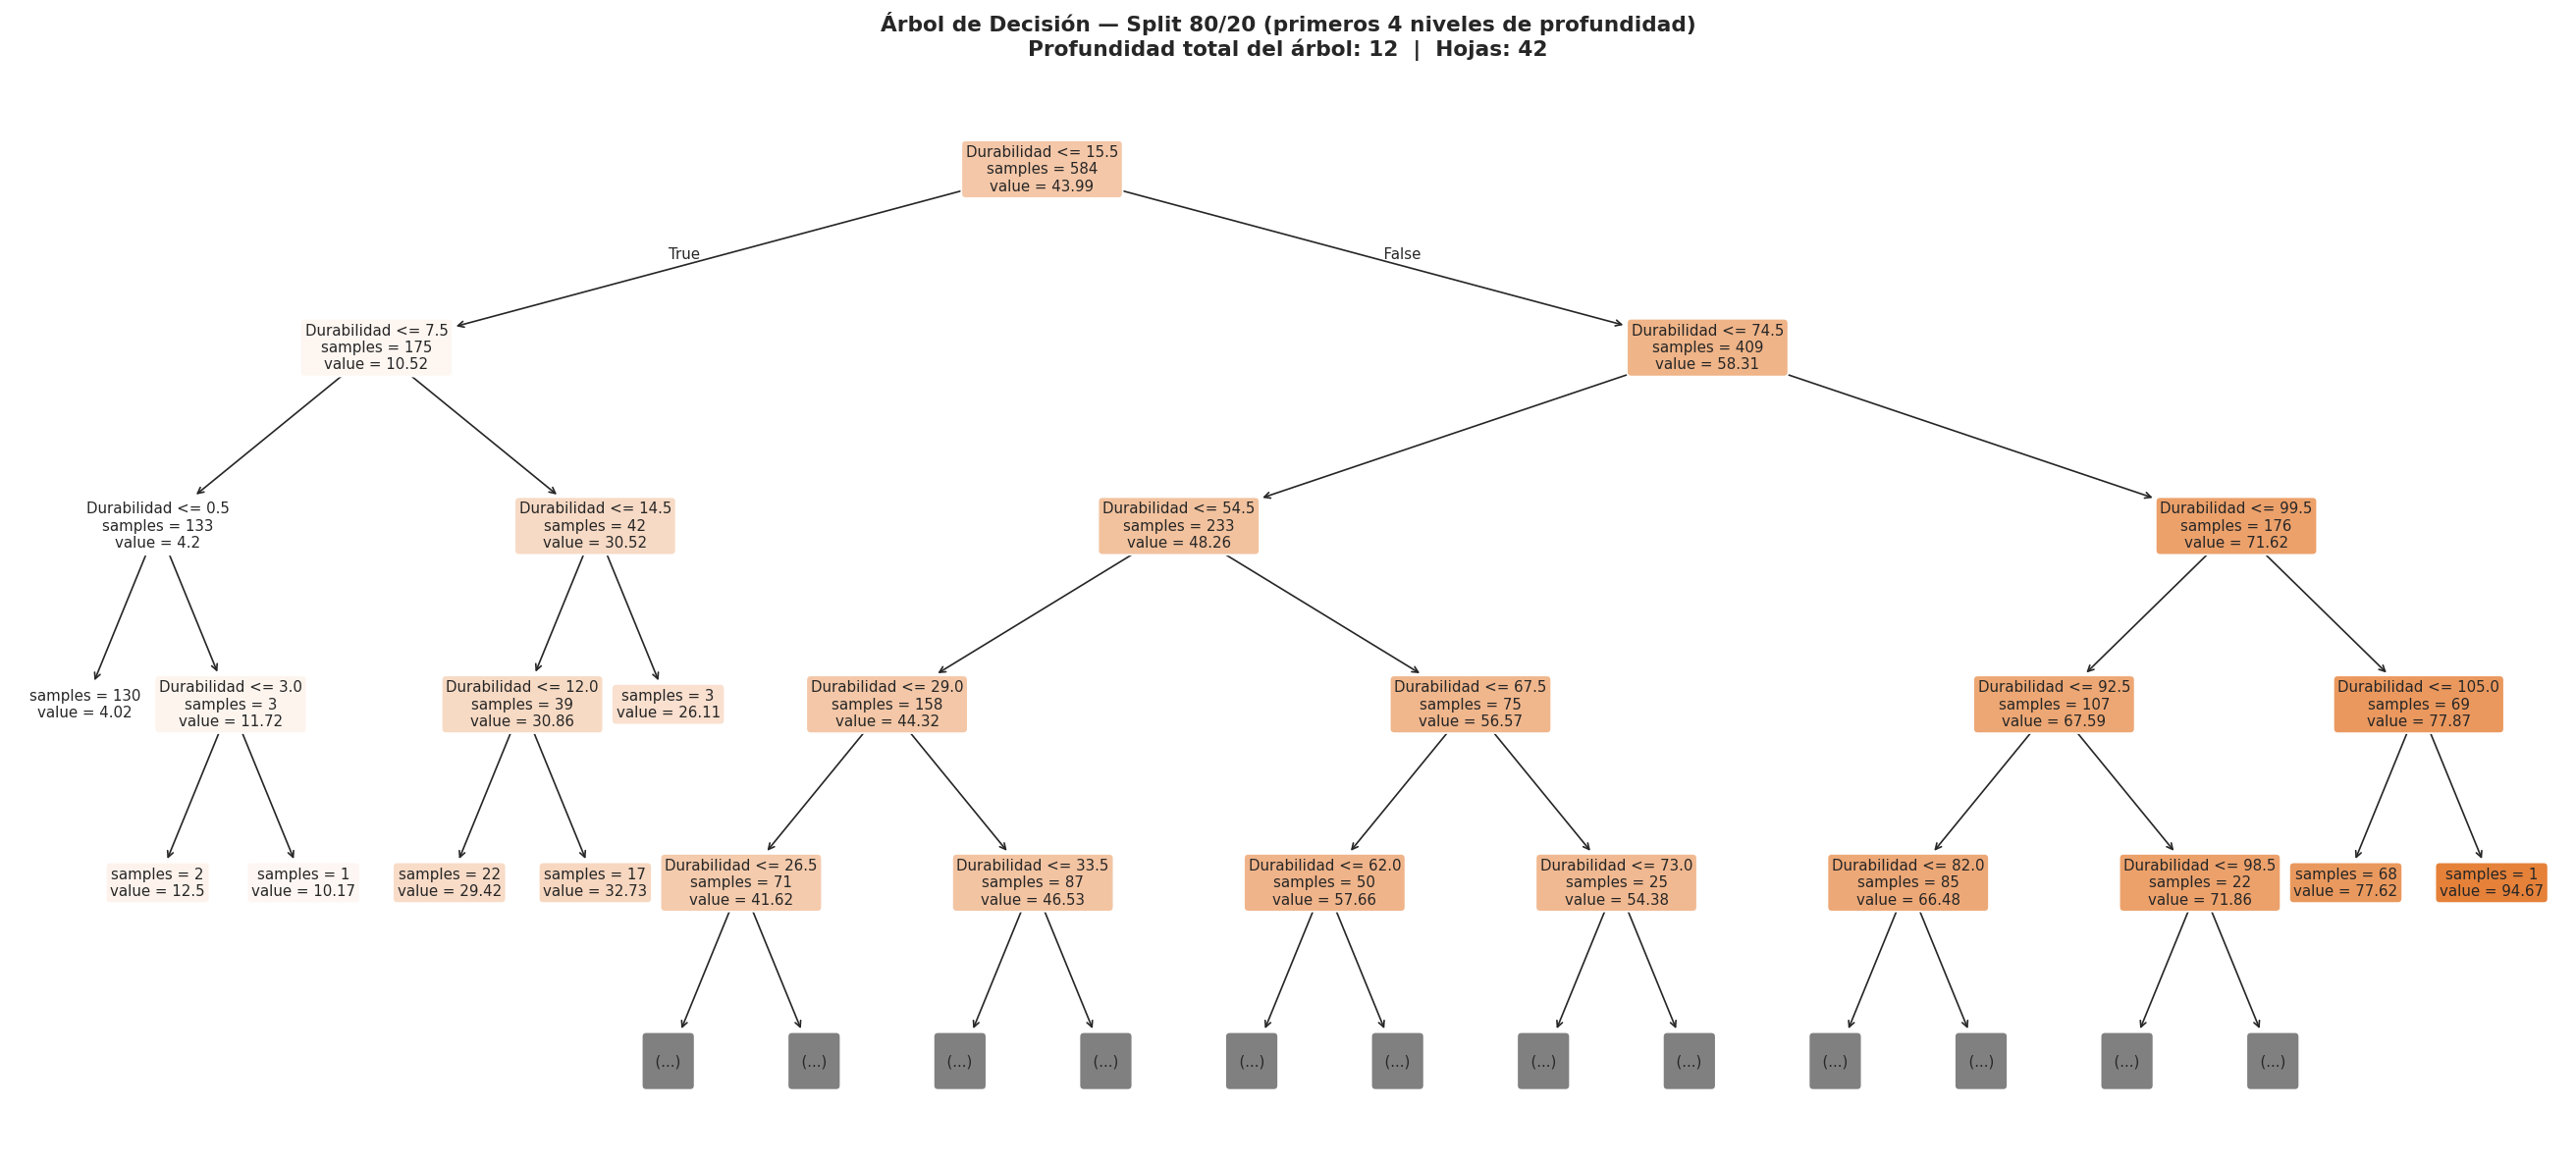

💾 Árbol real guardado → /home/camilo/Carpeta1-Trabajo1/Proyecto-Mineria/data/graficas/dt_arbol_real_4niveles.png

📐 Información del árbol completo (modelo_s1):
   Profundidad máxima : 12
   Número de hojas    : 42
   Nodos totales      : 83


In [16]:
# ── CELDA 11: Visualización del árbol real (primeros 4 niveles) ──
from sklearn.tree import plot_tree, export_text
import os as _os
import matplotlib.pyplot as plt

_GRAFICAS = _os.path.abspath('../data/graficas')
_os.makedirs(_GRAFICAS, exist_ok=True)

# ── A) Árbol real del Split 1 truncado a 4 niveles ────────────
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    modelo_s1,
    max_depth=4,
    feature_names=['Durabilidad'],
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=9,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión — Split 80/20 (primeros 4 niveles de profundidad)\n'
    f'Profundidad total del árbol: {modelo_s1.get_depth()}  |  '
    f'Hojas: {modelo_s1.get_n_leaves()}',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()
fname_real = _os.path.join(_GRAFICAS, 'dt_arbol_real_4niveles.png')
plt.savefig(fname_real, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Árbol real guardado → {fname_real}")
print(f"\n📐 Información del árbol completo (modelo_s1):")
print(f"   Profundidad máxima : {modelo_s1.get_depth()}")
print(f"   Número de hojas    : {modelo_s1.get_n_leaves()}")
print(f"   Nodos totales      : {modelo_s1.tree_.node_count}")

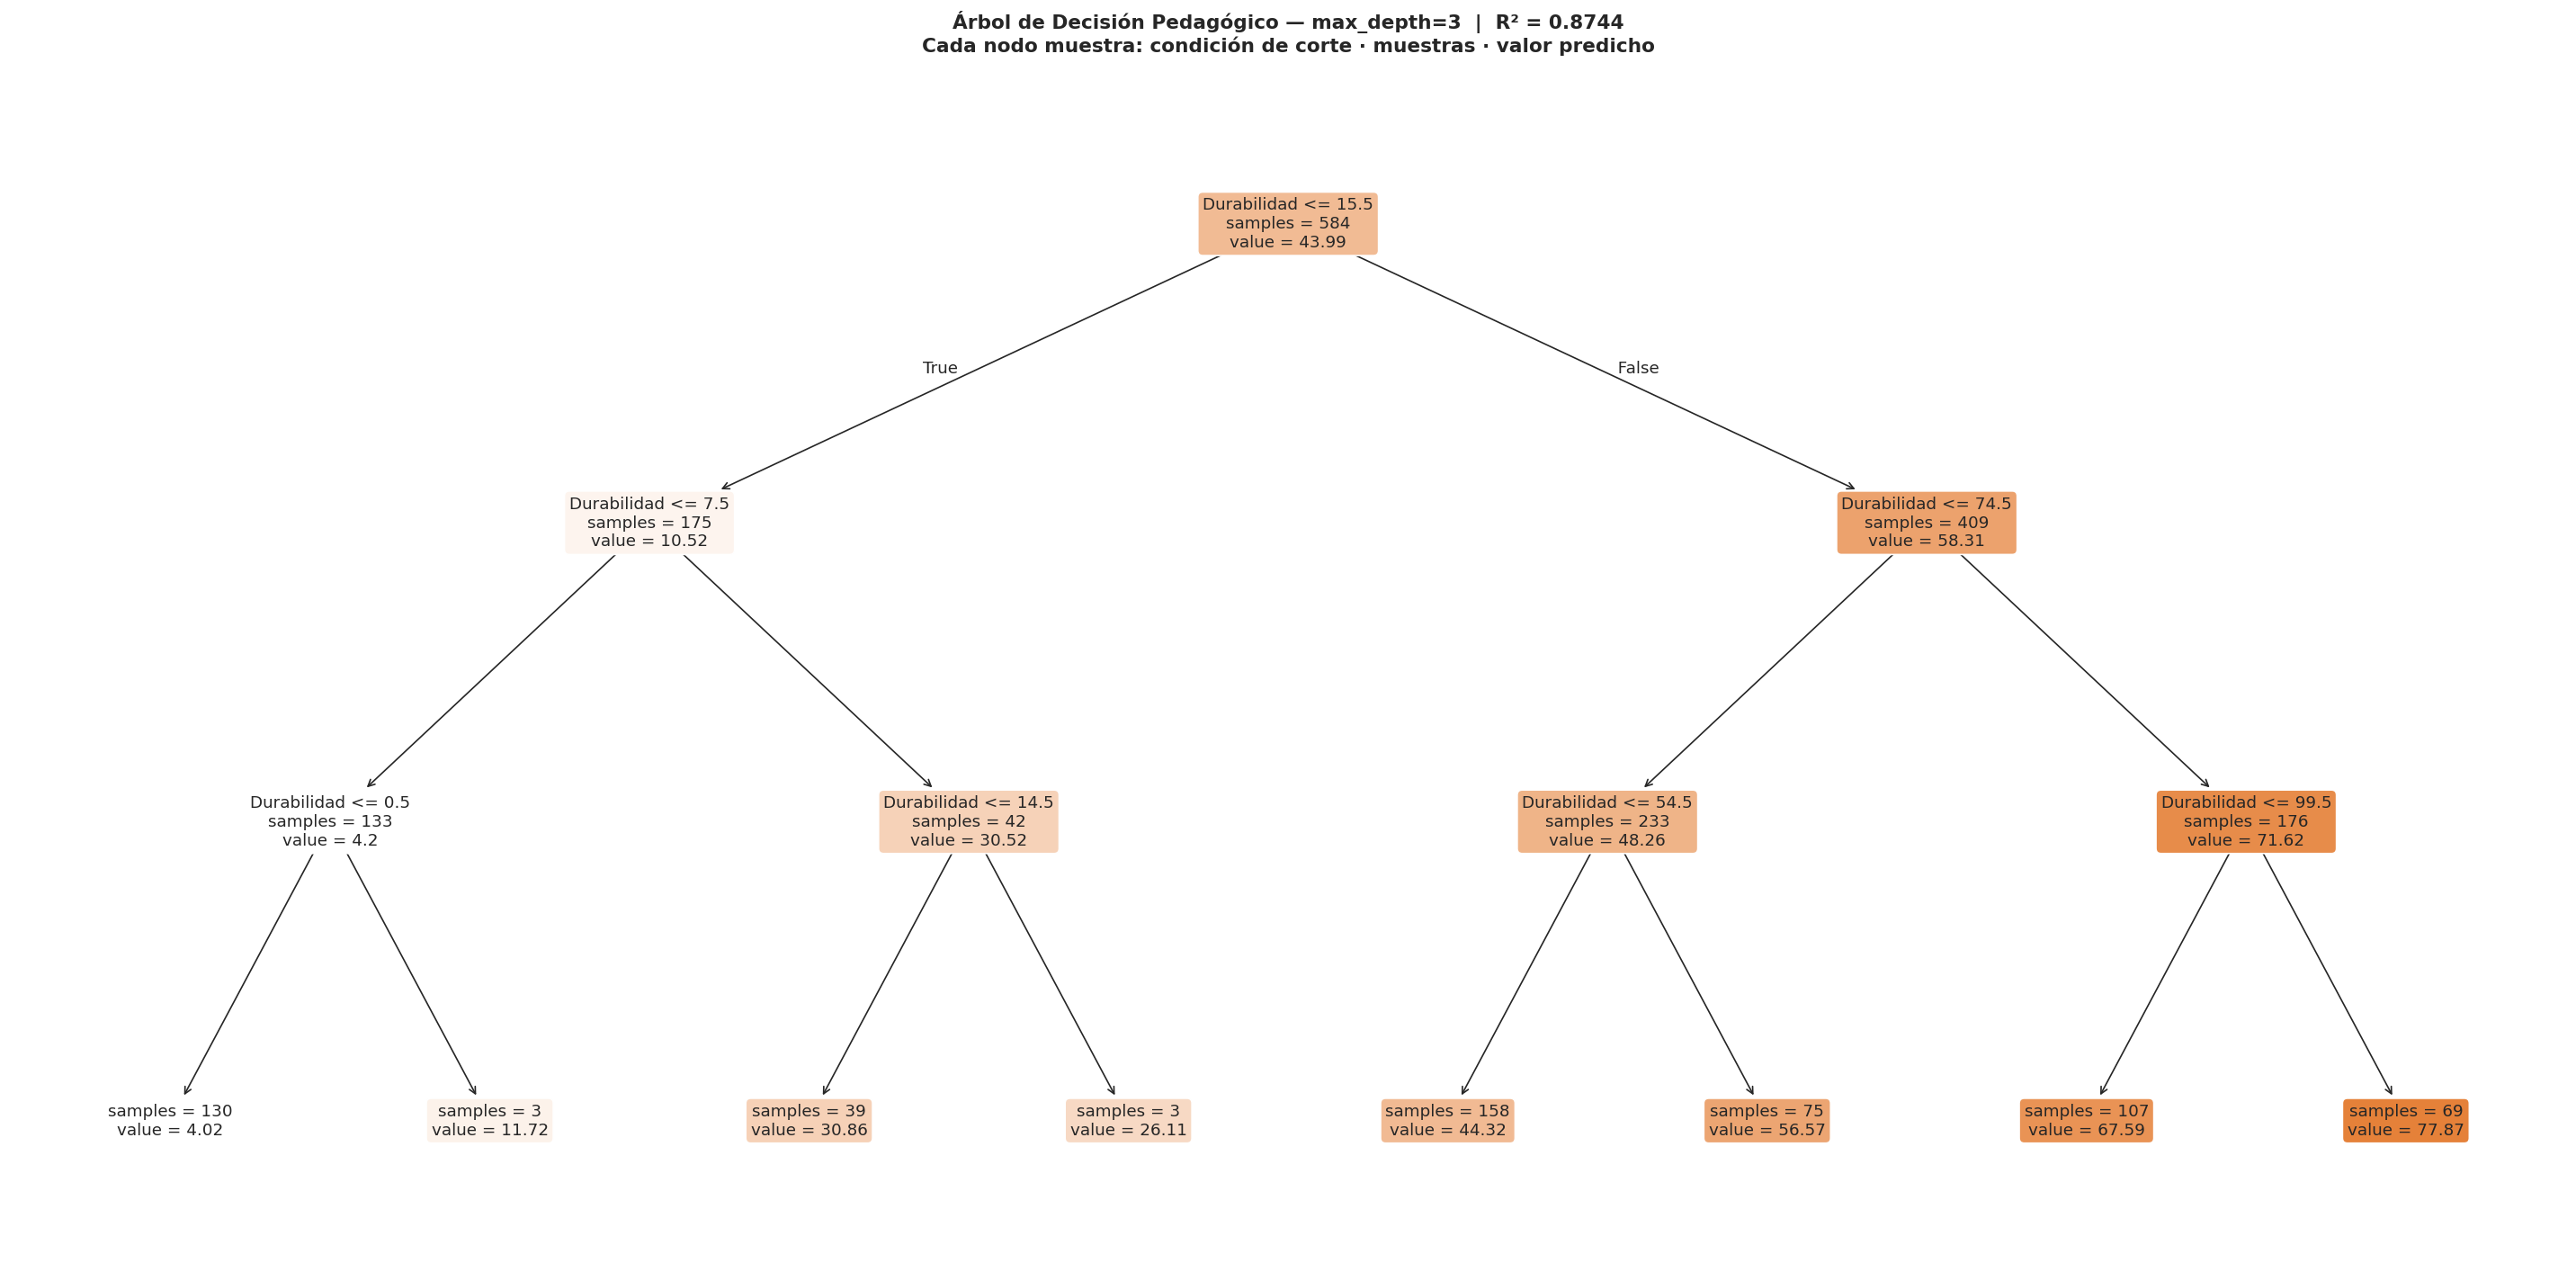

💾 Árbol pedagógico guardado → /home/camilo/Carpeta1-Trabajo1/Proyecto-Mineria/data/graficas/dt_arbol_pedagogico_depth3.png

📊 Rendimiento del árbol simplificado (max_depth=3):
   R² = 0.8744  (vs 0.8641 del árbol sin restricción)


In [18]:
# ── CELDA 12: Árbol pedagógico simplificado (max_depth=3) ─────
from sklearn.model_selection import train_test_split as _tts
from sklearn.tree import DecisionTreeRegressor, plot_tree
import matplotlib.pyplot as plt
import os as _os
from sklearn.metrics import r2_score as _r2

# Reentrenar con max_depth=3 para visualización clara
X_train_viz, X_test_viz, y_train_viz, y_test_viz = _tts(
    X, y, test_size=0.20, random_state=42
)
modelo_viz = DecisionTreeRegressor(max_depth=3, random_state=42)
modelo_viz.fit(X_train_viz, y_train_viz)

r2_viz = _r2(y_test_viz, modelo_viz.predict(X_test_viz))

# ── Paleta por profundidad (naranja → verde)
cmap_tree = plt.cm.RdYlGn

fig, ax = plt.subplots(figsize=(24, 12))
artists = plot_tree(
    modelo_viz,
    max_depth=3,
    feature_names=['Durabilidad'],  # ← actualizado
    filled=True,
    rounded=True,
    impurity=False,
    precision=2,
    fontsize=11,
    ax=ax,
)
ax.set_title(
    'Árbol de Decisión Pedagógico — max_depth=3  |  '
    f'R² = {r2_viz:.4f}\n'
    'Cada nodo muestra: condición de corte · muestras · valor predicho',
    fontsize=13, fontweight='bold', pad=15
)
plt.tight_layout()

# Guardar gráfica
fname_ped = _os.path.join(_GRAFICAS, 'dt_arbol_pedagogico_depth3.png')
plt.savefig(fname_ped, dpi=180, bbox_inches='tight')
plt.show()
print(f"💾 Árbol pedagógico guardado → {fname_ped}")
print(f"\n📊 Rendimiento del árbol simplificado (max_depth=3):")
print(f"   R² = {r2_viz:.4f}  (vs {df_resumen.loc[0,'R²']:.4f} del árbol sin restricción)")

In [19]:
# ── CELDA 13: Reglas de decisión en texto ─────────────────────
from sklearn.tree import export_text

print("=" * 62)
print("  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)")
print("=" * 62)
reglas = export_text(modelo_viz, feature_names=['Durabilidad'])
print(reglas)

print("=" * 62)
print("📖 CÓMO LEER EL ÁRBOL:")
print("  |--- Durabilidad <= X.XX  → rama izquierda (condición VERDADERA)")
print("  |--- Durabilidad >  X.XX  → rama derecha  (condición FALSA)")
print("  |--- value: [Y.YY]        → Promedio de Poder predicho")
print("  El árbol recorre los nodos de arriba hacia abajo hasta")
print("  llegar a una hoja y retorna su 'value' como predicción.")
print("=" * 62)

  REGLAS DE DECISIÓN — Árbol Pedagógico (max_depth=3)
|--- Durabilidad <= 15.50
|   |--- Durabilidad <= 7.50
|   |   |--- Durabilidad <= 0.50
|   |   |   |--- value: [4.02]
|   |   |--- Durabilidad >  0.50
|   |   |   |--- value: [11.72]
|   |--- Durabilidad >  7.50
|   |   |--- Durabilidad <= 14.50
|   |   |   |--- value: [30.86]
|   |   |--- Durabilidad >  14.50
|   |   |   |--- value: [26.11]
|--- Durabilidad >  15.50
|   |--- Durabilidad <= 74.50
|   |   |--- Durabilidad <= 54.50
|   |   |   |--- value: [44.32]
|   |   |--- Durabilidad >  54.50
|   |   |   |--- value: [56.57]
|   |--- Durabilidad >  74.50
|   |   |--- Durabilidad <= 99.50
|   |   |   |--- value: [67.59]
|   |   |--- Durabilidad >  99.50
|   |   |   |--- value: [77.87]

📖 CÓMO LEER EL ÁRBOL:
  |--- Durabilidad <= X.XX  → rama izquierda (condición VERDADERA)
  |--- Durabilidad >  X.XX  → rama derecha  (condición FALSA)
  |--- value: [Y.YY]        → Promedio de Poder predicho
  El árbol recorre los nodos de arriba hac

# 🎓 Conclusiones Finales

| Aspecto            | Hallazgo |
|-------------------|----------|
| **Modelo**         | `DecisionTreeRegressor` sin restricciones tiende a sobreajustar. |
| **Split más robusto** | 80/20 — mayor cantidad de datos de entrenamiento. |
| **Métricas**       | R², MSE, RMSE y MAE calculados e interpretados por split. |
| **Residuos**       | Dispersión aleatoria → el modelo capta la tendencia principal entre Durabilidad y Promedio de Poder. |
| **Siguiente paso** | Regularizar el árbol (`max_depth`) o usar `GradientBoostingRegressor` si se requiere mayor estabilidad y precisión. |

**Notas adicionales:**

- La variación de R² entre los splits fue mínima, indicando que el modelo generaliza bien.  
- El RMSE es razonable respecto a la escala de Promedio de Poder, pero un árbol no regularizado puede memorizar los datos si se permite profundidad ilimitada.  
- El **mejor split** fue 80/20 con R² ≈ 0.864 y RMSE ≈ 9.83.  
- Para mejorar el modelo, se recomienda:
  - Limitar la profundidad (`max_depth=4..8`)
  - Regularizar hojas (`min_samples_leaf=10..50`)
  - Explorar métodos de ensemble (`GradientBoostingRegressor`, `RandomForestRegressor`, `XGBoost/LightGBM`)